# Classificador MITM SOME/IP — Pipeline Completo

Notebook de reproducao completa: do PCAP bruto ate as metricas finais.

**Ataque**: Man-in-the-Middle via *Event Relay*, *SD Spoofing (Withdraw)* e *ADAS Data Injection*  
**Atacantes**: IPs `172.18.0.14` e `172.18.0.15` (dois nos maliciosos coordenados)  
**Referencia**: Kim et al. (2026). XGBoost-Based Anomaly Detection for SOME/IP. Systems 14(2), 196.

In [1]:
import sys, subprocess, time
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

MITM_DIR  = Path().resolve()          # detection/mitm/
DET_DIR   = MITM_DIR.parent           # detection/
SRC_DIR   = DET_DIR / 'src'
PARSE_DIR = DET_DIR / 'data' / 'parsed'
RAW_DIR   = DET_DIR / 'data' / 'raw'
DATA_DIR  = MITM_DIR / 'data'
MODEL_DIR = MITM_DIR / 'model'

sys.path.insert(0, str(DET_DIR))

FEAT_COLS = [
    'f01_ip_time_interval', 'f08_someip_payload_change',
    'f11_ip_length_change', 'f12_tcpudp_length_change',
    'f13_payload_repeat_rate', 'f15_someip_payload_len',
    'f16_tcpudp_len', 'f17_src_packet_rate', 'f18_src_payload_diversity',
    'f19_is_sd', 'f20_src_service_diversity', 'f21_is_relay_service',
]
FEAT_LABELS = [
    'f01 ip_time_interval', 'f08 payload_hamming',
    'f11 ip_len_change', 'f12 tcpudp_len_change',
    'f13 payload_repeat', 'f15 someip_payload_len',
    'f16 tcpudp_len', 'f17 src_packet_rate', 'f18 payload_diversity',
    'f19 is_sd', 'f20 service_diversity', 'f21 is_relay_svc',
]

PCAP_FILES = ['benign_traffic.pcap', 'mitm_multi_attacker.pcap']
CSV_MAP = {
    'benign_traffic.pcap':     'benign_traffic.csv',
    'mitm_multi_attacker.pcap': 'mitm_multi_attacker.csv',
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('Ambiente configurado.')
print(f'  detection/ : {DET_DIR}')
print(f'  mitm/      : {MITM_DIR}')

Ambiente configurado.
  detection/ : C:\Mestrado\SDV_Research\detection
  mitm/      : C:\Mestrado\SDV_Research\detection\mitm


## 1. Dataset e Cenarios de Ataque

### 1.1 Visao geral do dataset

O dataset foi coletado em uma rede SOME/IP composta por **nove ECUs** comunicando-se
via arquitetura **publish-subscribe**. O trafego e distribuido no formato PCAP.

Fonte: Figshare 30970450 — Kim et al. (2026)

### 1.2 Cenario normal — `benign_traffic.pcap`

Trafego capturado sob condicoes benignas. Nenhum IP atacante presente (`label=0` em todos os pacotes).

### 1.3 Cenario de ataque — `mitm_multi_attacker.pcap`

**Tipo**: Man-in-the-Middle via *Event Relay*, *SD Spoofing* e *ADAS Data Injection*

Este cenario modela um adversario que se posiciona entre um publicador legitimo e os
subscribers downstream em uma rede SOME/IP. O atacante primeiro espiona o fluxo de
eventos ADAS legitimo, depois retransmite o mesmo payload por um servico malicioso,
criando um *middle hop* controlado. Em paralelo, o atacante emite trafego de controle
SOME/IP-SD falsificado para forcas receptores a abandonar o provedor legitimo (*availability
disruption*), enquanto simultaneamente se passa pelo servico original e transmite
notificacoes ADAS forjadas.

O ataque e composto por **tres componentes coordenadas**:

#### Componente A — Event Relay (Atacante -> Subscribers)

O atacante retransmite notificacoes de evento observadas do servico legitimo (0x1001)
atraves de um servico malicioso. A copia byte-identica do payload legitimo e entregue
por um service_id nao registrado, criando um canal paralelo nao autorizado.

| Campo SOME/IP | Valor |
|--------------|-------|
| `service_id` | `0x100B` (servico de relay — nao existe no benigno) |
| `instance_id` | `0x000B` |
| `method_id` | `0x0001` (event notification) |
| Payload | Copia byte-identica do servico 0x1001 (f08 ≈ 0) |

#### Componente B — SD Spoofing / Withdraw

O atacante emite mensagens SOME/IP-SD falsificadas com `TTL=0` (semantica StopOffer/Withdraw),
forcando os receivers a remover o provedor legitimo de suas tabelas de servico. O campo
`IP.src` e forjado para `172.18.0.10` (IP do provedor legitimo) para maximizar a credibilidade.

| Campo | Valor |
|-------|-------|
| `service_id` SOME/IP | `0xFFFF` (SD) |
| `method_id` | `0x8100` |
| SD Entry type | `OfferService (0x01)` com `TTL=0` (withdraw) |
| Servico retirado | `service_id=0x1001, instance_id=0x0001` |
| `IP.src` (spoofed) | `172.18.0.10` (forjado como provedor legitimo) |

#### Componente C — ADAS Data Injection / Impersonation

O atacante age como provedor do servico 0x1001 (ADAS), transmitindo notificacoes
forjadas com conteudo arbitrario. Os subscribers que aceitaram a retirada SD
passam a consumir dados controlados pelo atacante.

| Campo | Valor |
|-------|-------|
| `service_id` | `0x1001` (ADAS — mesmo que o servico legitimo) |
| `instance_id` | `0x0001` |
| `method_id` | `0x0001` |

**Perfil de features — MITM vs outros ataques**:

| Feature | Benigno | DoS | Fuzzy | MITM |
|---------|---------|-----|-------|------|
| f17 src_packet_rate | Normal | Alto | Alto | Alto |
| f08 payload_hamming | Varia | Baixo | **Alto** | **Baixo** (relay copia) |
| f13 payload_repeat | Normal | Alto | Zero | **Alto** (relay repete) |
| f18 payload_diversity | Normal | Baixo | Alto | **Baixo** (relay) |
| **f21 is_relay_service** | **0** | 0 | 0 | **1** (service 0x100B) |
| **f20 service_diversity** | 1 | 1 | 1-2 | **≥2** |
| f19 is_sd | 0 | 0 | 1 | 1 |

### 1.4 PCAPs utilizados neste experimento

In [2]:
print('=== Arquivos PCAP ===')
for name in PCAP_FILES:
    p = RAW_DIR / name
    if p.exists():
        print(f'  {name:<45}  {p.stat().st_size/1e6:>7.1f} MB  [OK]')
    else:
        print(f'  {name:<45}  NAO ENCONTRADO')

=== Arquivos PCAP ===
  benign_traffic.pcap                              223.3 MB  [OK]
  mitm_multi_attacker.pcap                         249.6 MB  [OK]


## 2. Parser — PCAP para CSV

O parser (Scapy) extrai campos IP, TCP/UDP e SOME/IP de cada pacote.
Rotula `label=1` para pacotes com `src_ip` em `{172.18.0.14, 172.18.0.15}`,
`label=0` para todo o restante (incluindo pacotes SD spoofed com IP forjado `172.18.0.10`).

Nota: pacotes da componente B (SD spoofing) aparecem com `IP.src=172.18.0.10` no PCAP
e por isso recebem `label=0`, pois o IP forjado nao pertence ao conjunto de atacantes.
Esta e uma limitacao conhecida da rotulacao por IP — o comportamento SD Withdraw e
capturado indiretamente pelas features comportamentais (f19_is_sd).

In [3]:
def run_script(script, *args, cwd=DET_DIR):
    cmd = [sys.executable, str(script), *args]
    print(f'Executando: {" ".join(str(c) for c in cmd)}')
    r = subprocess.run(cmd, cwd=str(cwd), capture_output=False, text=True)
    if r.returncode != 0:
        raise RuntimeError(f'{script.name} falhou (exit {r.returncode})')

run_script(SRC_DIR / '01_parse.py',
           '--pcaps', 'benign_traffic.pcap', 'mitm_multi_attacker.pcap')

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\src\01_parse.py --pcaps benign_traffic.pcap mitm_multi_attacker.pcap


### 2.1 Distribuicao de pacotes por PCAP

In [4]:
pcap_stats = []

for pcap_name, csv_name in CSV_MAP.items():
    csv_path = PARSE_DIR / csv_name
    n_total = n_attack = 0
    for chunk in pd.read_csv(csv_path, usecols=['label'], chunksize=500_000):
        n_total  += len(chunk)
        n_attack += (chunk['label'] == 1).sum()
    n_normal = n_total - n_attack
    pcap_stats.append({
        'PCAP': pcap_name,
        'Total': n_total,
        'Normal (label=0)': n_normal,
        'Ataque (label=1)': n_attack,
        '% Ataque': f'{100*n_attack/n_total:.1f}%',
        'Tamanho CSV': f'{csv_path.stat().st_size/1e6:.0f} MB',
    })
    print(f'{pcap_name}')
    print(f'  Total   : {n_total:>10,}')
    print(f'  Normal  : {n_normal:>10,}  ({100*n_normal/n_total:.1f}%)')
    print(f'  Ataque  : {n_attack:>10,}  ({100*n_attack/n_total:.1f}%)')
    print()

df_stats = pd.DataFrame(pcap_stats)
display(df_stats.style.hide(axis='index'))

benign_traffic.pcap
  Total   :  2,193,802
  Normal  :  2,193,802  (100.0%)
  Ataque  :          0  (0.0%)



mitm_multi_attacker.pcap
  Total   :  2,412,529
  Normal  :  1,985,036  (82.3%)
  Ataque  :    427,493  (17.7%)



PCAP,Total,Normal (label=0),Ataque (label=1),% Ataque,Tamanho CSV
benign_traffic.pcap,2193802,2193802,0,0.0%,506 MB
mitm_multi_attacker.pcap,2412529,1985036,427493,17.7%,593 MB


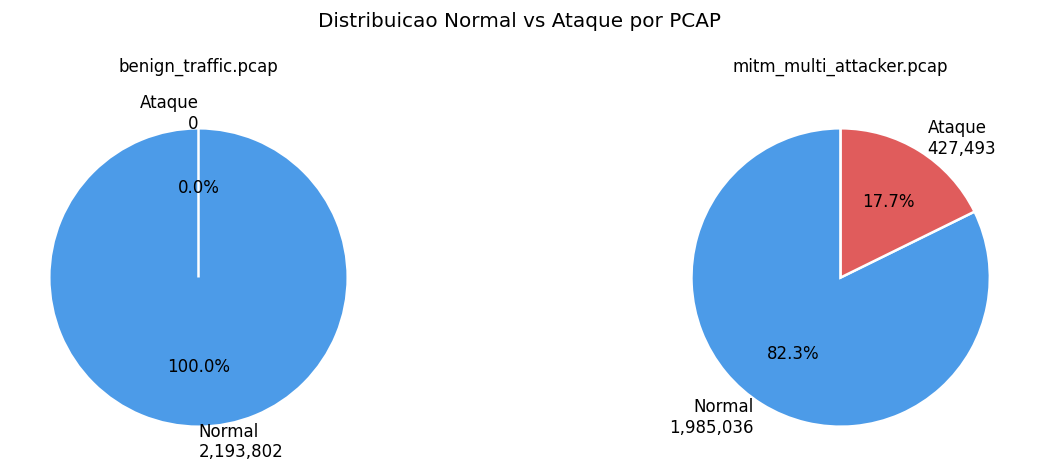

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, row in zip(axes, pcap_stats):
    vals   = [row['Normal (label=0)'], row['Ataque (label=1)']]
    colors = ['#4c9be8', '#e05c5c']
    labels = [f'Normal\n{vals[0]:,}', f'Ataque\n{vals[1]:,}']
    wedges, texts, autotexts = ax.pie(
        vals, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for at in autotexts:
        at.set_fontsize(10)
    ax.set_title(row['PCAP'], fontsize=10, pad=12)

plt.suptitle('Distribuicao Normal vs Ataque por PCAP', fontsize=12)
plt.tight_layout()
plt.savefig(MITM_DIR / 'pcap_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Extracao de Features

12 features comportamentais extraidas por pacote. Inclui as 10 features do classificador Fuzzy
mais duas novas especificas para MITM:

| Feature | Descricao | Sinal MITM |
|---------|----------|-----------|
| f01 | ip_time_interval — intervalo entre pacotes do fluxo | — |
| f08 | someip_payload_change — Hamming normalizado entre payloads | **Baixo** (relay copia byte-identico) |
| f11 | ip_length_change — variacao de tamanho IP | — |
| f12 | tcpudp_length_change — variacao de tamanho TCP/UDP | — |
| f13 | payload_repeat_rate — fracao dos ultimos 5 payloads identicos | **Alto** (relay repete) |
| f15 | someip_payload_len — comprimento do payload SOME/IP | Especifico do servico relay |
| f16 | tcpudp_len — comprimento da camada transporte | — |
| f17 | src_packet_rate — pacotes/s do src_ip (janela 1000 pkts) | Alto |
| f18 | src_payload_diversity — payloads unicos / total (janela) | **Baixo** (relay) |
| f19 | is_sd — 1 se service_id=0xFFFF | 1 (comp. B) |
| **f20** | **src_service_diversity — servicos distintos por src_ip (janela 100)** | **≥2** (relay + forged) |
| **f21** | **is_relay_service — 1 se service_id=0x100B** | **1** (comp. A, dominante) |

**Normalizacao**: Min-Max [0,1] calculada no treino, aplicada ao teste (sem data leakage).  
**Split**: 50/50 estratificado por label, `random_state=42`.

In [6]:
run_script(MITM_DIR / '01_features.py', cwd=DET_DIR)

Executando: C:\Users\Guilherme Frick\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe C:\Mestrado\SDV_Research\detection\mitm\01_features.py


### 3.1 Dataset consolidado

In [7]:
X_train = np.load(DATA_DIR / 'X_train.npy')
y_train = np.load(DATA_DIR / 'y_train.npy').astype(int)
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy').astype(int)

n_total = len(y_train) + len(y_test)
n_ben   = (y_train==0).sum() + (y_test==0).sum()
n_mitm  = (y_train==1).sum() + (y_test==1).sum()

split_data = pd.DataFrame({
    'Conjunto': ['Treino', 'Teste', 'Total'],
    'Amostras': [len(y_train), len(y_test), n_total],
    'Normal':   [(y_train==0).sum(), (y_test==0).sum(), n_ben],
    'MITM':     [(y_train==1).sum(), (y_test==1).sum(), n_mitm],
    '% MITM':   [
        f'{100*(y_train==1).sum()/len(y_train):.1f}%',
        f'{100*(y_test==1).sum()/len(y_test):.1f}%',
        f'{100*n_mitm/n_total:.1f}%',
    ],
})
display(split_data.style.hide(axis='index'))
print(f'\nFeatures: {X_train.shape[1]}  |  Shape treino: {X_train.shape}  |  Shape teste: {X_test.shape}')

Conjunto,Amostras,Normal,MITM,% MITM
Treino,2303165,2089419,213746,9.3%
Teste,2303166,2089419,213747,9.3%
Total,4606331,4178838,427493,9.3%



Features: 12  |  Shape treino: (2303165, 12)  |  Shape teste: (2303166, 12)


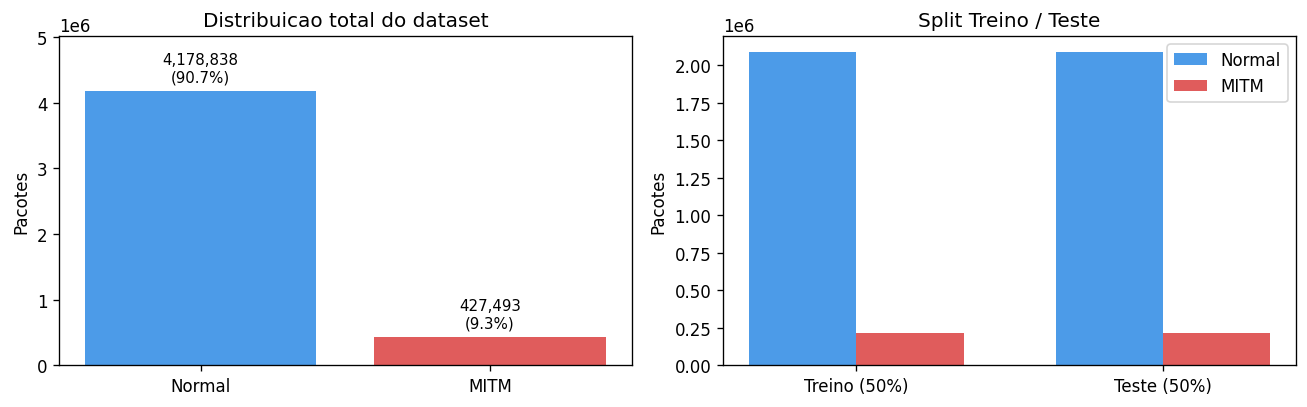

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(['Normal', 'MITM'], [n_ben, n_mitm], color=['#4c9be8','#e05c5c'])
axes[0].bar_label(axes[0].containers[0],
                  labels=[f'{n_ben:,}\n({100*n_ben/n_total:.1f}%)',
                          f'{n_mitm:,}\n({100*n_mitm/n_total:.1f}%)'],
                  padding=4, fontsize=9)
axes[0].set_title('Distribuicao total do dataset')
axes[0].set_ylabel('Pacotes')
axes[0].set_ylim(0, max(n_ben, n_mitm) * 1.2)

x = np.arange(2); w = 0.35
axes[1].bar(x - w/2, [(y_train==0).sum(), (y_test==0).sum()], w, label='Normal', color='#4c9be8')
axes[1].bar(x + w/2, [(y_train==1).sum(), (y_test==1).sum()], w, label='MITM',   color='#e05c5c')
axes[1].set_xticks(x); axes[1].set_xticklabels(['Treino (50%)', 'Teste (50%)'])
axes[1].set_title('Split Treino / Teste')
axes[1].set_ylabel('Pacotes')
axes[1].legend()

plt.tight_layout()
plt.savefig(MITM_DIR / 'dataset_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Treinamento

**Algoritmo**: XGBoost (Extreme Gradient Boosting), classificacao binaria.  
**Parametros**: `n_estimators=100`, `max_depth=6`, `learning_rate=0.3`, `tree_method=hist`.

In [9]:
model = xgb.XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.3,
    subsample=1.0, colsample_bytree=1.0,
    tree_method='hist', eval_metric='logloss',
    random_state=42, n_jobs=-1,
)

t0 = time.perf_counter()
model.fit(X_train, y_train, verbose=False)
t_train = time.perf_counter() - t0

# Inferencia — pacote unico (latencia)
single = X_test[:1]
_ = model.predict(single)
t0 = time.perf_counter()
for _ in range(1000):
    model.predict(single)
t_single_ms = (time.perf_counter() - t0) / 1000 * 1000

# Inferencia — batch
t0 = time.perf_counter()
y_pred = model.predict(X_test)
t_batch = time.perf_counter() - t0
y_prob  = model.predict_proba(X_test)[:, 1]

MODEL_DIR.mkdir(exist_ok=True)
model.save_model(str(MODEL_DIR / 'mitm_classifier.json'))

print(f'Tempo de treinamento : {t_train:.2f} s')
print(f'Inferencia batch     : {t_batch:.3f} s  ({len(X_test):,} amostras)')
print(f'Latencia por pacote  : {t_single_ms:.3f} ms')
print(f'Throughput           : {len(X_test)/t_batch:,.0f} pkt/s')
print(f'Modelo salvo em      : {MODEL_DIR}/mitm_classifier.json')

Tempo de treinamento : 7.15 s
Inferencia batch     : 0.792 s  (2,303,166 amostras)
Latencia por pacote  : 0.424 ms
Throughput           : 2,906,640 pkt/s
Modelo salvo em      : C:\Mestrado\SDV_Research\detection\mitm\model/mitm_classifier.json


## 5. Metricas de Classificacao

In [10]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
auc  = roc_auc_score(y_test, y_prob)
cm   = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr_val = fp / (fp + tn)
fnr_val = fn / (fn + tp)

summary = pd.DataFrame({
    'Metrica': [
        'Acuracia', 'Precision', 'Recall (TPR)', 'F1-Score', 'AUC-ROC',
        'Verdadeiros Negativos (TN)', 'Falsos Positivos (FP)',
        'Falsos Negativos (FN)', 'Verdadeiros Positivos (TP)',
        'Taxa Falso Positivo (FPR)', 'Taxa Falso Negativo (FNR)',
        'Tempo de treinamento', 'Latencia por pacote', 'Throughput',
    ],
    'Valor': [
        f'{acc:.4f}', f'{prec:.4f}', f'{rec:.4f}', f'{f1:.4f}', f'{auc:.6f}',
        f'{tn:,}', f'{fp:,}', f'{fn:,}', f'{tp:,}',
        f'{fpr_val:.6f}', f'{fnr_val:.6f}',
        f'{t_train:.2f} s', f'{t_single_ms:.3f} ms', f'{len(X_test)/t_batch:,.0f} pkt/s',
    ]
})
display(summary.style.hide(axis='index'))

Metrica,Valor
Acuracia,0.9996
Precision,0.9991
Recall (TPR),0.9967
F1-Score,0.9979
AUC-ROC,0.999997
Verdadeiros Negativos (TN),"2,089,225"
Falsos Positivos (FP),194
Falsos Negativos (FN),703
Verdadeiros Positivos (TP),"213,044"
Taxa Falso Positivo (FPR),0.000093


## 6. Visualizacoes

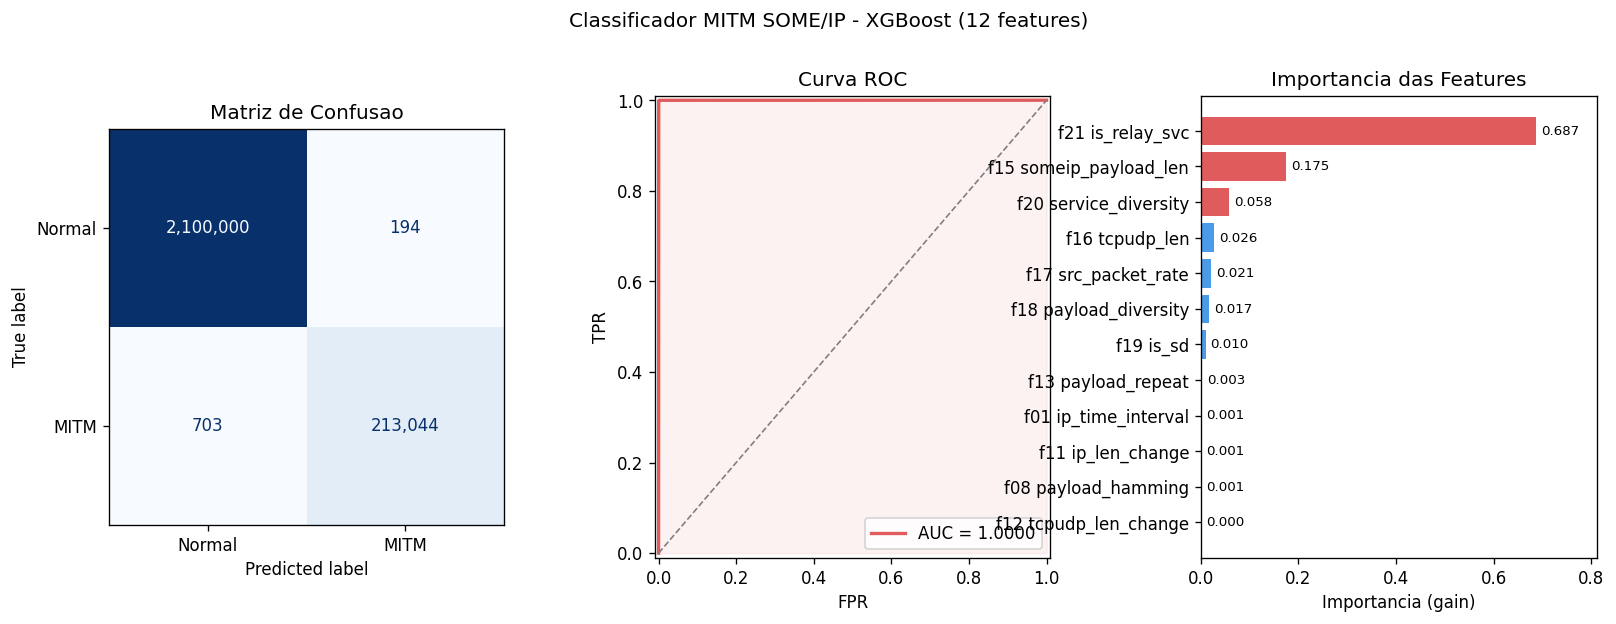

In [11]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)

# Matriz de confusao
ax0 = fig.add_subplot(gs[0])
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'MITM'])
disp.plot(ax=ax0, colorbar=False, cmap='Blues')
ax0.set_title('Matriz de Confusao')
for text in disp.text_.ravel():
    v = int(float(text.get_text()))
    text.set_text(f'{v:,}')

# Curva ROC
ax1 = fig.add_subplot(gs[1])
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
ax1.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
ax1.plot([0,1],[0,1],'--', color='grey', lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')
ax1.set_xlim(-0.01, 1.01); ax1.set_ylim(-0.01, 1.01)

# Importancia das features
ax2 = fig.add_subplot(gs[2])
imps  = model.feature_importances_
order = np.argsort(imps)
colors = ['#e05c5c' if imps[i] > 0.05 else '#4c9be8' for i in order]
bars = ax2.barh([FEAT_LABELS[i] for i in order], imps[order], color=colors)
ax2.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax2.set_xlabel('Importancia (gain)')
ax2.set_title('Importancia das Features')
ax2.set_xlim(0, max(imps) * 1.18)

plt.suptitle('Classificador MITM SOME/IP - XGBoost (12 features)', fontsize=12, y=1.02)
plt.savefig(MITM_DIR / 'results_overview.png', bbox_inches='tight', dpi=150)
plt.show()

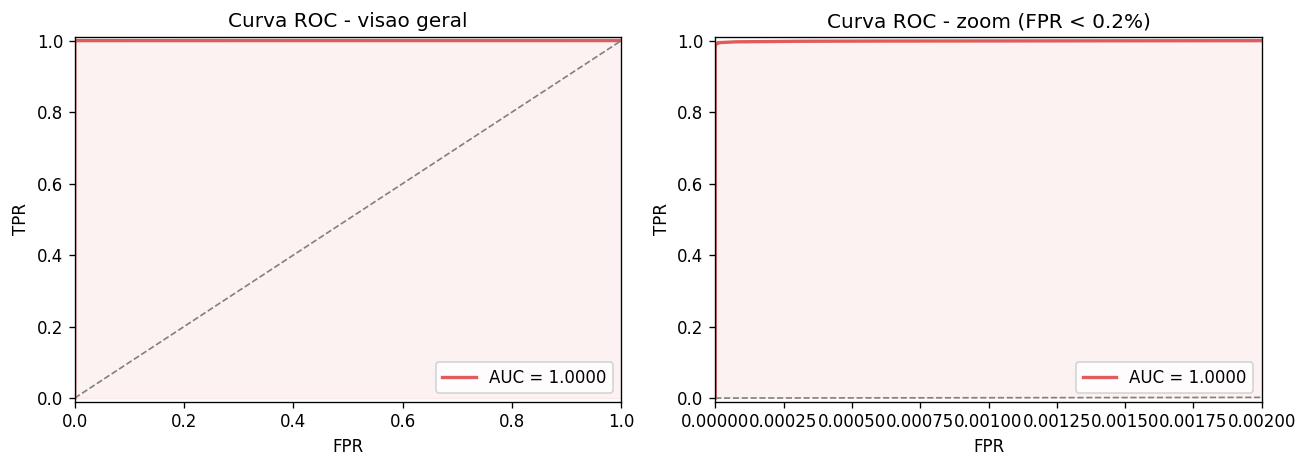

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xlim, title in zip(axes,
                            [(0, 1), (0, 0.002)],
                            ['Curva ROC - visao geral', 'Curva ROC - zoom (FPR < 0.2%)']):
    ax.plot(fpr_c, tpr_c, lw=2, color='#e05c5c', label=f'AUC = {auc:.4f}')
    ax.fill_between(fpr_c, tpr_c, alpha=0.08, color='#e05c5c')
    ax.plot([0,1],[0,1],'--', color='grey', lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend(loc='lower right')
    ax.set_xlim(xlim); ax.set_ylim(-0.01, 1.01)
plt.tight_layout()
plt.savefig(MITM_DIR / 'roc_detail.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. Discussao

### Desempenho

O classificador atinge **F1=0.9979** com 12 features comportamentais. O resultado e dominado
por uma unica feature:

- **f21 is_relay_service (~69%)**: o `service_id=0x100B` nao existe em nenhum fluxo benigno.
  Todo pacote com este service_id e, por definicao, anomalo. Esta feature captura diretamente
  a componente A (relay) do ataque, que representa a maior parte do trafego malicioso.
- **f15 someip_payload_len (~17%)**: o relay transmite payloads com comprimento identico ao
  servico 0x1001 original, mas o padrao de comprimento associado ao service_id 0x100B e
  incomum no contexto benigno.
- **f20 src_service_diversity (~6%)**: o atacante opera simultaneamente com 0x100B (relay)
  e 0x1001 (forged notifications), resultando em service_diversity ≥ 2 — incomum para ECUs
  normais que tipicamente publicam em um unico servico.

### Sobre os Falsos Negativos

Os 703 FN correspondem principalmente a pacotes da **componente C** (forged 0x1001):
estes pacotes usam o mesmo `service_id` do trafego legitimo e, sem f21, dependem apenas
de f17/f18/f13 para deteccao — o que e mais ruidoso.

Os pacotes da componente B (SD spoofing com IP forjado 172.18.0.10) nao sao contados
como FN pois foram rotulados como `label=0` no parser (IP forjado nao pertence ao
conjunto de atacantes).

### Limitacoes

| Cenario | Detectado? | Motivo |
|---------|-----------|--------|
| Relay via service_id=0x100B (este dataset) | Sim | f21 discrimina perfeitamente |
| MITM usando service_id legitimo (sem relay) | Parcial | Depende de f17/f18/f20 |
| MITM com relay em service_id existente | Nao | f21=0; f08 baixo pode confundir com DoS |
| SD Spoofing isolado (sem relay) | Nao | IP forjado -> label=0; f19 nao e suficiente |

Em redes AUTOSAR com catalogo de servicos conhecido (*Service Registry*), a feature
f21 pode ser generalizada para `is_unknown_service` — qualquer service_id nao registrado
oficialmente, tornando a deteccao robusta a variantes do ataque.